# EDA and Data Integrity

Inspect dataset size, file integrity, annotation coverage, and target distributions.

## 1. Setup

Define paths, columns, and analysis constants.

In [1]:
from pathlib import Path
from typing import Final, cast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.container import BarContainer

In [2]:
METADATA_PATH: Final = Path("../data/training_df.pkl")
TRAINING_DIR: Final = Path("../data/train/dicoms")
ANNOTATIONS_DIR: Final = Path("../data/train/annotations")

MLS_THRESHOLD_MM: Final = 3.0

SERIES_ID_COLUMN: Final = "dicom_series.id"
PATIENT_ID_COLUMN: Final = "dicom_series.PatientID"
INSTANCE_UID_COLUMN: Final = "dicom_series.SeriesInstanceUID"
SLICE_THICKNESS_COLUMN: Final = "dicom_series.SliceThickness"
FRACTURE_COLUMN: Final = "SkullFracture"
MLS_COLUMN: Final = "MidlineShiftMM"
ANY_ICH_COLUMN: Final = "AnyICH"
TRIAGE_COLUMN: Final = "triage_class"

ICH_COLUMNS: Final = [
    ANY_ICH_COLUMN,
    "IntraventricularHemorrhage",
    "IntraparenchymalHemorrhage",
    "SubarachnoidHemorrhage",
    "EpiduralHemorrhage",
    "SubduralHemorrhage",
]

REQUIRED_COLUMNS: Final = {
    SERIES_ID_COLUMN,
    PATIENT_ID_COLUMN,
    INSTANCE_UID_COLUMN,
    SLICE_THICKNESS_COLUMN,
    FRACTURE_COLUMN,
    MLS_COLUMN,
    TRIAGE_COLUMN,
    *ICH_COLUMNS,
}

## 2. Load Data

Load metadata and validate the required columns.

In [3]:
metadata = pd.read_pickle(METADATA_PATH)

if metadata.empty:
    raise ValueError("Metadata is empty.")

missing_columns = REQUIRED_COLUMNS - set(metadata.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

metadata[[SLICE_THICKNESS_COLUMN, MLS_COLUMN]] = metadata[
    [SLICE_THICKNESS_COLUMN, MLS_COLUMN]
].apply(pd.to_numeric, errors="coerce")

print(f"Slices: {len(metadata):,}")
metadata.head()

Slices: 7,508


,dicom_series.id,dicom_series.NumDicomFiles,dicom_series.PatientID,dicom_series.StudyInstanceUID,dicom_series.SeriesInstanceUID,dicom_series.SOPInstanceUID,dicom_series.PixelSpacing0,dicom_series.PixelSpacing1,dicom_series.SliceThickness,IntraventricularHemorrhage,...,IntraventricularHemorrhage_Area,IntraparenchymalHemorrhage_Area,SubarachnoidHemorrhage_Area,EpiduralHemorrhage_Area,SubduralHemorrhage_Area,SkullFracture,MidlineShiftMM,RelativeAnnotationPath,AnyICH,triage_class
0,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_beba6a8e7,0.488281,0.488281,5.06,False,...,0,0,0,0,0,False,0.1,271208/ID_beba6a8e7.json,False,2
1,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_e482af39d,0.488281,0.488281,5.06,False,...,0,0,0,0,0,False,0.1,271208/ID_e482af39d.json,False,2
2,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_4f4c7acd0,0.488281,0.488281,5.06,False,...,0,0,0,0,0,False,0.1,271208/ID_4f4c7acd0.json,False,2
3,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_a39f8e984,0.488281,0.488281,5.06,False,...,0,895,0,0,0,False,0.1,271208/ID_a39f8e984.json,True,2
4,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_36d6d9505,0.488281,0.488281,5.06,False,...,0,1575,0,0,0,False,0.1,271208/ID_36d6d9505.json,True,2


In [4]:
dataset_summary = pd.Series(
    {
        "Slices": len(metadata),
        "Patients": metadata[PATIENT_ID_COLUMN].nunique(dropna=True),
        "DICOM Series": metadata[SERIES_ID_COLUMN].nunique(dropna=True),
        "Columns": metadata.shape[1],
    },
    name="Count",
)

display(dataset_summary.to_frame())

,Count
Slices,7508
Patients,320
DICOM Series,338
Columns,24


## 3. Series Summary

Aggregate slice-level metadata into one row per DICOM series.

In [5]:
def nunique_all(values: pd.Series) -> int:
    """Count unique values, including missing values."""
    return values.nunique(dropna=False)

In [6]:
series_metadata = (
    metadata.groupby(SERIES_ID_COLUMN, as_index=False, dropna=False)
    .agg(
        patient_id=(PATIENT_ID_COLUMN, "first"),
        patient_count=(PATIENT_ID_COLUMN, nunique_all),
        instance_uid=(INSTANCE_UID_COLUMN, "first"),
        instance_uid_count=(INSTANCE_UID_COLUMN, nunique_all),
        num_slices=(INSTANCE_UID_COLUMN, "size"),
        slice_thickness=(SLICE_THICKNESS_COLUMN, "median"),
        skull_fracture=(FRACTURE_COLUMN, "any"),
        max_midline_shift_mm=(MLS_COLUMN, "max"),
        any_ich=(ANY_ICH_COLUMN, "any"),
        triage_class=(TRIAGE_COLUMN, "first"),
        triage_count=(TRIAGE_COLUMN, nunique_all),
    )
    .rename(columns={SERIES_ID_COLUMN: "series_id"})
)

series_metadata["metadata_mismatch"] = (
    series_metadata["patient_count"].gt(1)
    | series_metadata["instance_uid_count"].gt(1)
    | series_metadata["triage_count"].gt(1)
)

series_metadata.head()

,series_id,patient_id,patient_count,instance_uid,instance_uid_count,num_slices,slice_thickness,skull_fracture,max_midline_shift_mm,any_ich,triage_class,triage_count,metadata_mismatch
0,447,127716,1,1.2.392.200036.9116.2.6.1.15596.4012038373.163...,1,29,5.0,False,17.149502,True,2,1,False
1,465,129026,1,1.2.392.200036.9116.2.6.1.15596.4012038373.163...,1,29,5.0,False,12.194207,True,2,1,False
2,515,144567,1,1.2.392.200036.9116.2.6.1.44063.1811171443.162...,1,28,5.0,False,2.845519,True,2,1,False
3,519,14615,1,1.2.392.200036.9116.2.6.1.15596.4012038373.163...,1,35,5.0,False,7.173704,True,2,1,False
4,554,157781,1,1.2.392.200036.9116.2.6.1.44063.1811171443.161...,1,27,5.0,False,4.685939,True,1,1,False


## 4. File Integrity

Compare expected slice counts with files stored on disk.

In [7]:
def count_files(directory: Path, series_id: int | str) -> int:
    """Count files for one DICOM series."""
    series_dir = directory / str(series_id)

    if not series_dir.is_dir():
        return 0

    return sum(path.is_file() for path in series_dir.iterdir())

In [8]:
series_metadata["training_files"] = series_metadata["series_id"].map(
    lambda series_id: count_files(TRAINING_DIR, series_id)
)

series_metadata["annotation_files"] = series_metadata["series_id"].map(
    lambda series_id: count_files(ANNOTATIONS_DIR, series_id)
)
series_metadata["is_annotated"] = series_metadata["annotation_files"].gt(0)

series_metadata["training_mismatch"] = series_metadata["training_files"].ne(
    series_metadata["num_slices"]
)

In [9]:
series_metadata["annotation_mismatch"] = series_metadata[
    "is_annotated"
] & series_metadata["annotation_files"].ne(series_metadata["num_slices"])

series_metadata["integrity_error"] = series_metadata["training_mismatch"]
integrity_errors = series_metadata.loc[series_metadata["integrity_error"]].copy()

In [10]:
print(f"Total series         : {len(series_metadata):,}")
print(f"Integrity errors     : {len(integrity_errors):,}")
print(f"Training mismatches  : {series_metadata['training_mismatch'].sum():,}")

Total series         : 338
Integrity errors     : 27
Training mismatches  : 27


In [11]:
if not integrity_errors.empty:
    columns = [
        "series_id",
        "patient_id",
        "num_slices",
        "training_files",
        "annotation_files",
        "metadata_mismatch",
        "training_mismatch",
        "annotation_mismatch",
    ]

    display(integrity_errors[columns])

,series_id,patient_id,num_slices,training_files,annotation_files,metadata_mismatch,training_mismatch,annotation_mismatch
8,658,192895,13,29,0,False,True,False
26,985,254978,27,29,0,False,True,False
62,1952,689602,21,29,21,False,True,False
70,2023,700862,23,29,0,False,True,False
79,2200,755624,10,16,10,False,True,False
83,2305,766821,2,16,0,False,True,False
85,2336,767131,16,0,0,False,True,False
89,2388,767333,9,16,9,False,True,False
98,2557,767996,10,16,0,False,True,False
100,2575,768066,7,16,0,False,True,False


## 5. Clinical Distributions

Inspect slice thickness and maximum midline shift.

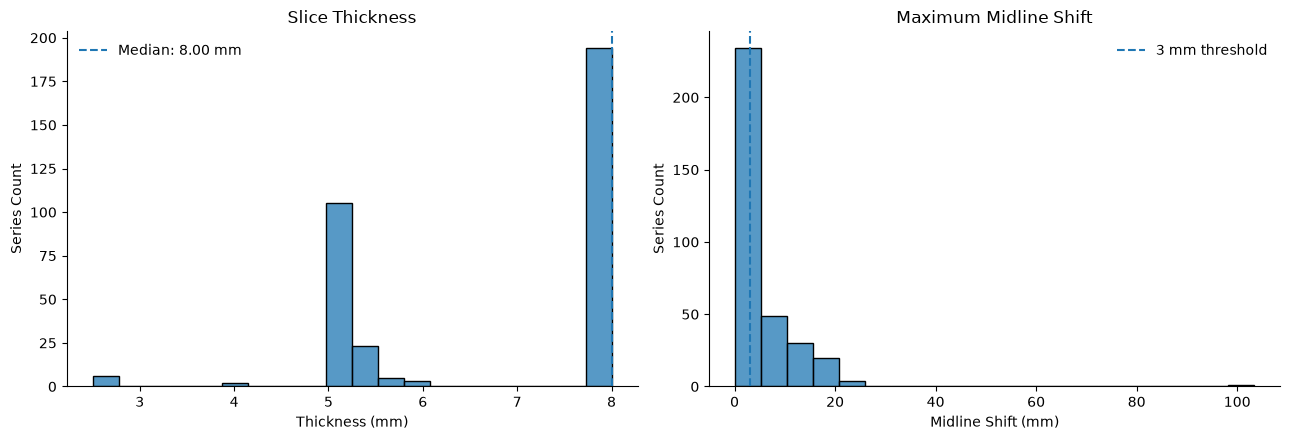

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

median_thickness = series_metadata["slice_thickness"].median()

sns.histplot(data=series_metadata, x="slice_thickness", bins=20, ax=axes[0])
axes[0].axvline(
    median_thickness,
    linestyle="--",
    label=f"Median: {median_thickness:.2f} mm",
)
axes[0].set(
    title="Slice Thickness",
    xlabel="Thickness (mm)",
    ylabel="Series Count",
)
axes[0].legend(frameon=False)

sns.histplot(
    data=series_metadata,
    x="max_midline_shift_mm",
    bins=20,
    ax=axes[1],
)
axes[1].axvline(
    MLS_THRESHOLD_MM,
    linestyle="--",
    label=f"{MLS_THRESHOLD_MM:g} mm threshold",
)
axes[1].set(
    title="Maximum Midline Shift",
    xlabel="Midline Shift (mm)",
    ylabel="Series Count",
)
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

## 6. Annotation Coverage

Measure the number of annotated and unannotated series.

In [13]:
annotation_coverage = (
    series_metadata["is_annotated"]
    .map({True: "Annotated", False: "Unannotated"})
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

annotation_coverage["percentage"] = (
    annotation_coverage["count"] / len(series_metadata) * 100
)

display(annotation_coverage.style.format({"percentage": "{:.1f}%"}))

,status,count,percentage
0,Annotated,193,57.1%
1,Unannotated,145,42.9%


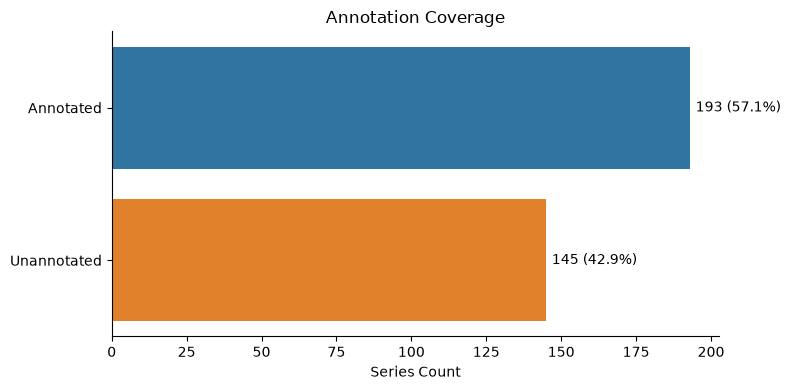

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=annotation_coverage,
    x="count",
    y="status",
    hue="status",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    bar_container = cast(BarContainer, container)
    labels = [
        f"{int(bar.get_width())} ({bar.get_width() / len(series_metadata):.1%})"
        for bar in bar_container
    ]
    ax.bar_label(bar_container, labels=labels, padding=4)

ax.set(
    title="Annotation Coverage",
    xlabel="Series Count",
    ylabel="",
)

sns.despine()
plt.tight_layout()
plt.show()

## 7. Series Size

Inspect the number of slices per DICOM series.

In [15]:
slice_counts = series_metadata["num_slices"]

slice_count_summary = (
    slice_counts.describe()
    .loc[["min", "25%", "50%", "mean", "75%", "max"]]
    .rename("slice_count")
    .to_frame()
)

display(slice_count_summary.style.format("{:.1f}"))

,slice_count
min,2.0
25%,16.0
50%,16.0
mean,22.2
75%,29.0
max,50.0


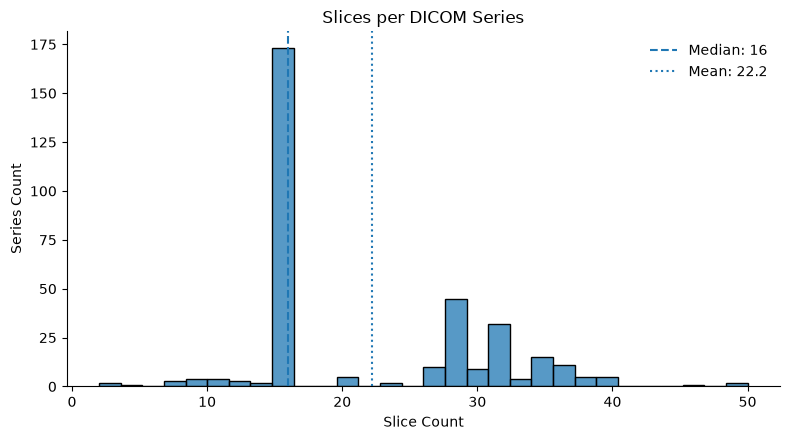

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.histplot(
    data=series_metadata,
    x="num_slices",
    bins=30,
    ax=ax,
)

median_slices = slice_counts.median()
mean_slices = slice_counts.mean()

ax.axvline(median_slices, linestyle="--", label=f"Median: {median_slices:.0f}")
ax.axvline(mean_slices, linestyle=":", label=f"Mean: {mean_slices:.1f}")
ax.set(
    title="Slices per DICOM Series",
    xlabel="Slice Count",
    ylabel="Series Count",
)
ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

## 8. ICH Prevalence

Measure slice-level prevalence for any ICH and each subtype.

In [17]:
ich_prevalence = (
    metadata[ICH_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("prevalence_pct")
    .rename_axis("condition")
    .reset_index()
)

display(ich_prevalence.style.format({"prevalence_pct": "{:.2f}%"}))

,condition,prevalence_pct
0,AnyICH,20.42%
1,IntraparenchymalHemorrhage,12.60%
2,SubduralHemorrhage,5.78%
3,IntraventricularHemorrhage,5.50%
4,SubarachnoidHemorrhage,2.57%
5,EpiduralHemorrhage,2.00%


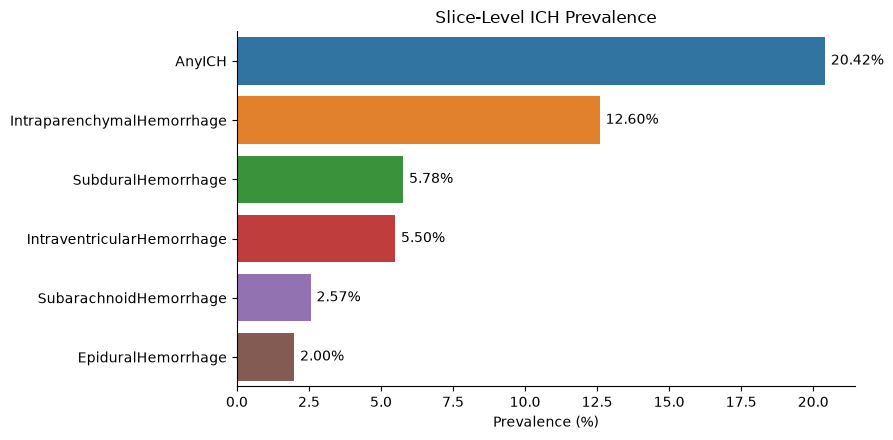

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.barplot(
    data=ich_prevalence,
    x="prevalence_pct",
    y="condition",
    hue="condition",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    bar_container = cast(BarContainer, container)
    ax.bar_label(bar_container, fmt="%.2f%%", padding=4)

ax.set(
    title="Slice-Level ICH Prevalence",
    xlabel="Prevalence (%)",
    ylabel="",
)

sns.despine()
plt.tight_layout()
plt.show()